In [5]:
import numpy as np
import torch as t
from matplotlib import pyplot as plt
from torch.utils.data import TensorDataset, DataLoader
import h5py

## Task 1: CNNs for Galaxy Classification

In [6]:
# create data folder if it does not exist
import os

if not os.path.exists("data/Galaxy10.h5"): # Does not need to download every time
    os.makedirs("data", exist_ok=True)

    import requests #urllib.request had some ssl issues
    response = requests.get("http://www.astro.utoronto.ca/~bovy/Galaxy10/Galaxy10.h5")
    with open("data/Galaxy10.h5", "wb") as f:
        f.write(response.content)

In [7]:
label_names = [
    'Disk, Face-on, No Spiral',
    'Smooth, Completely round',
    'Smooth, in-between round',
    'Smooth, Cigar shaped',
    'Disk, Edge-on, Rounded Bulge',
    'Disk, Edge-on, Boxy Bulge',
    'Disk, Edge-on, No Bulge',
    'Disk, Face-on, Tight Spiral',
    'Disk, Face-on, Medium Spiral',
    'Disk, Face-on, Loose Spiral'
]
n_classes = len(label_names)

# To get the images and labels from file
with h5py.File('data/Galaxy10.h5', 'r') as F:
    images = np.array(F['images'])
    labels = np.array(F['ans'])
images = images.astype(np.float32)

# comply to (batch, channel, height, width) convention of pytorch
images = np.moveaxis(images, -1, 1)  
# convert to torch
images = t.from_numpy(images)
labels = t.from_numpy(labels)

print(f'{images.shape=}, {labels.shape=}')

images.shape=torch.Size([21785, 3, 69, 69]), labels.shape=torch.Size([21785])


### (a)

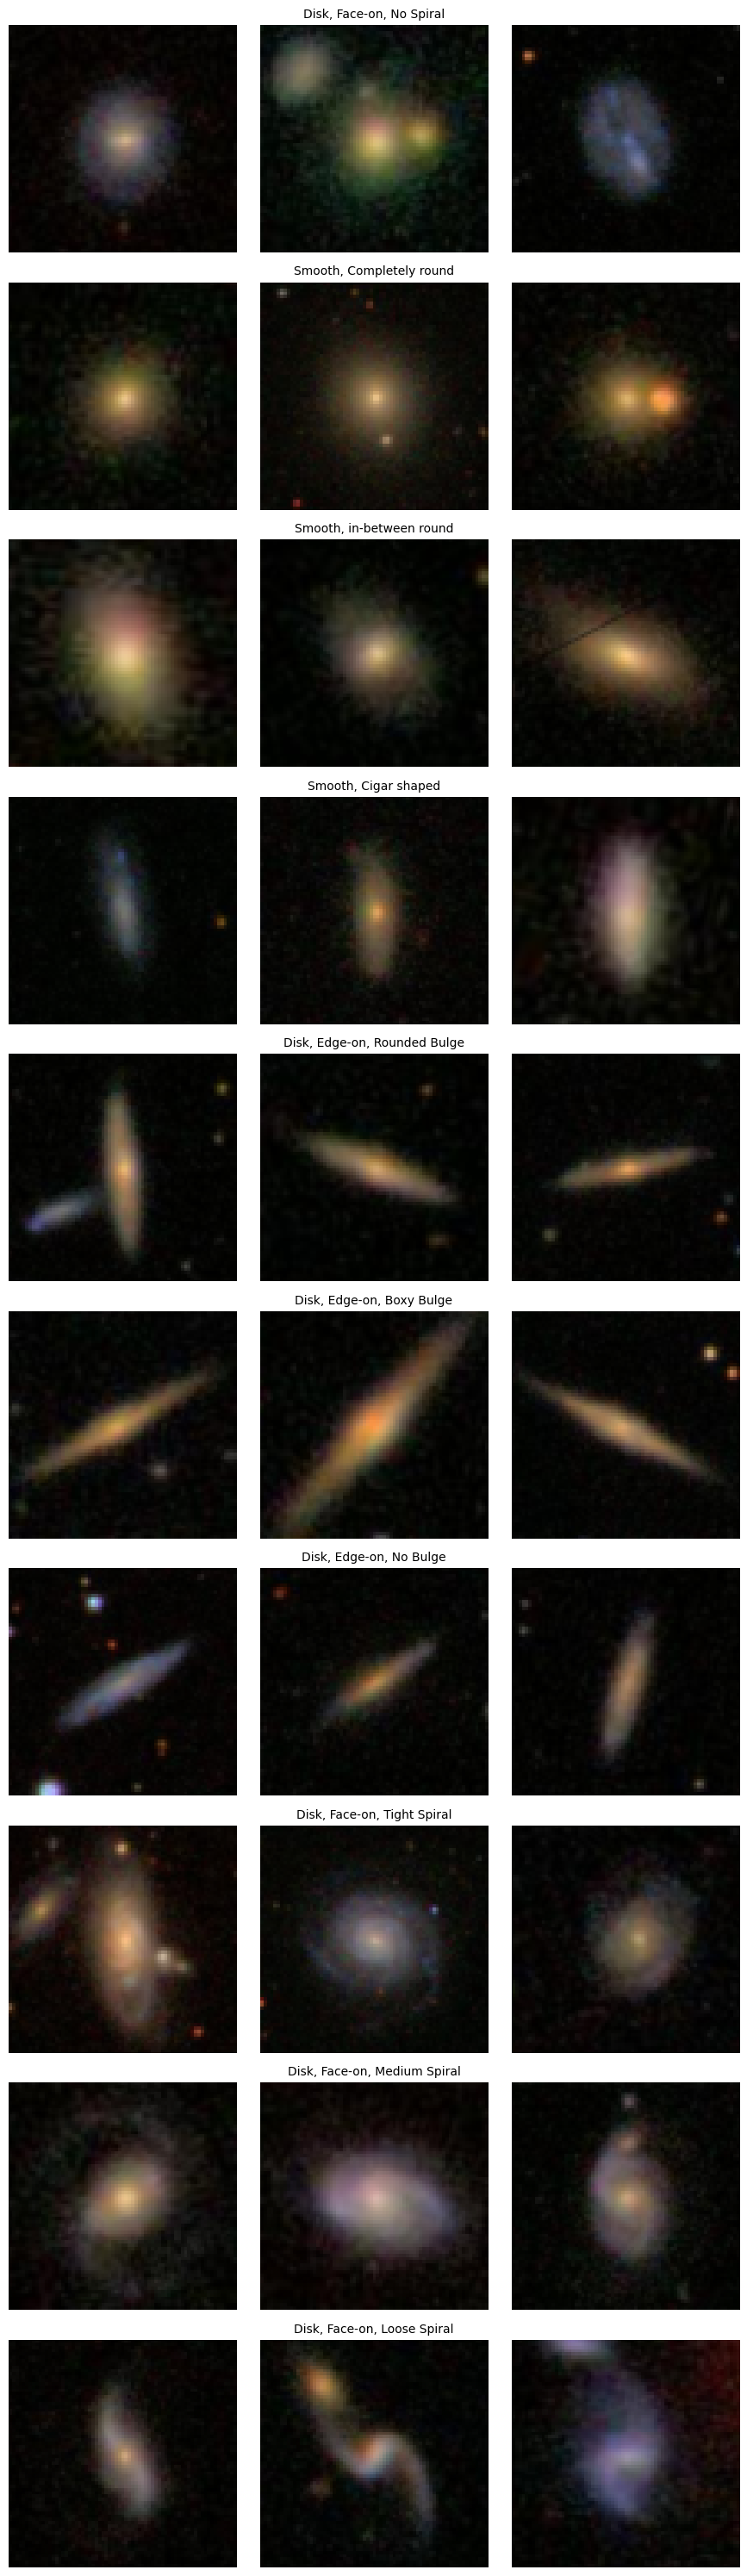

In [8]:
# TODO: plot three samples of each class

fig, axs = plt.subplots(n_classes, 3, figsize=(9, 3*n_classes))
for class_idx in range(n_classes):
    img_plot = images[labels == class_idx]/images.max()
    for sample_idx in range(3):
        axs[class_idx, sample_idx].imshow(img_plot[sample_idx].permute(1, 2, 0))
        axs[class_idx, sample_idx].axis('off')
        if sample_idx == 1:
            axs[class_idx, sample_idx].set_title(label_names[class_idx], fontsize=10)
plt.tight_layout()
plt.show()


In [9]:
from torchvision.transforms import Normalize
from sklearn.model_selection import train_test_split

# TODO: Split the data and normalize the images:

train_images, test_val_images, train_labels, test_val_labels = train_test_split(
    images, labels, test_size=0.2, random_state=42, stratify=labels
)

test_images, val_images, test_labels, val_labels = train_test_split(
    test_val_images, test_val_labels, test_size=0.5, random_state=42, stratify=test_val_labels
)

# TODO: Create tensordatasets and data loaders:

normalize = Normalize(mean=images.mean(dim=[0, 2, 3]), std=images.std(dim=[0, 2, 3]))
train_images = normalize(train_images)
val_images = normalize(val_images)
test_images = normalize(test_images)

train_dataset = TensorDataset(train_images, train_labels)
val_dataset = TensorDataset(val_images, val_labels)
test_dataset = TensorDataset(test_images, test_labels)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

### (b)

In [10]:
#TODO: implement a small CNN as specified on the sheet
from torch import nn

class GalaxyCNN(nn.Module):
    def __init__(self):
        super().__init__()
        
        self.conv1 = nn.Conv2d(in_channels=3, out_channels=8, kernel_size=5)
        self.pool = nn.MaxPool2d(kernel_size=2, stride=2)

        self.conv2 = nn.Conv2d(in_channels=8, out_channels=16, kernel_size=5)

        self.flattend_size = 16 * 14 * 14

        self.fc1 = nn.Linear(self.flattend_size, 64)
        self.fc2 = nn.Linear(64, 32)
        self.fc3 = nn.Linear(32, n_classes)

    def forward(self, x):
        x = self.pool(nn.functional.relu(self.conv1(x)))
        x = self.pool(nn.functional.relu(self.conv2(x)))
        x = x.view(-1, self.flattend_size)

        x = nn.functional.relu(self.fc1(x))
        x = nn.functional.relu(self.fc2(x))
        x = self.fc3(x)
        return x

### 

### (c)

In [11]:
# TODO: Instantiate the model, optimizer and criterion
model = GalaxyCNN()
device = t.device("cuda" if t.cuda.is_available() else "cpu")
model.to(device)

optimizer = t.optim.Adam(model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

### (d)

In [12]:
num_epochs = 30
train_losses = []
val_losses = []
val_accs = []

# TODO: Implement the training loop, validating after every epoch, and make the requested plots.

def train(model):
    model.train()
    
    for batch_images, batch_labels in train_loader:
        optimizer.zero_grad()
        outputs = model(batch_images)
        loss = criterion(outputs, batch_labels)
        loss.backward()
        optimizer.step()
        train_losses.append(loss.item())

def validate(model):
    losses = []
    correct = []

    #TODO: Implement the validation loop

    model.eval()
    with t.no_grad():
        for batch_images, batch_labels in val_loader:
            batch_images, batch_labels = batch_images.to(device), batch_labels.to(device)
            outputs = model(batch_images)
            loss = criterion(outputs, batch_labels)
            losses.append(loss.item())

            _, predicted = outputs.max(1)
            correct.append(predicted.eq(batch_labels).sum().item() / batch_labels.size(0))
    
    avg_loss = np.mean(np.array(losses))
    accuracy = np.mean(np.array(correct))
    print(f'{accuracy=:.2f}, {avg_loss=:.2e}')
    return avg_loss, accuracy

val_loss, val_acc = validate(model)
val_losses.append(val_loss)
val_accs.append(val_acc)
for epoch in range(num_epochs):
    # TODO: Implement the training loop, validating after every epoch and a visualization of the loss curves
    
    train(model)
    val_loss, val_acc = validate(model)
    val_losses.append(val_loss)
    val_accs.append(val_acc)

accuracy=0.07, avg_loss=2.29e+00
accuracy=0.57, avg_loss=1.12e+00
accuracy=0.64, avg_loss=9.71e-01
accuracy=0.65, avg_loss=9.31e-01
accuracy=0.68, avg_loss=8.50e-01
accuracy=0.70, avg_loss=8.31e-01
accuracy=0.72, avg_loss=7.99e-01
accuracy=0.71, avg_loss=8.16e-01
accuracy=0.74, avg_loss=7.40e-01
accuracy=0.72, avg_loss=8.02e-01
accuracy=0.74, avg_loss=7.43e-01
accuracy=0.73, avg_loss=7.30e-01
accuracy=0.73, avg_loss=7.32e-01
accuracy=0.74, avg_loss=7.38e-01
accuracy=0.76, avg_loss=7.16e-01
accuracy=0.75, avg_loss=7.41e-01
accuracy=0.74, avg_loss=8.01e-01
accuracy=0.75, avg_loss=8.05e-01
accuracy=0.76, avg_loss=7.60e-01
accuracy=0.74, avg_loss=8.52e-01
accuracy=0.73, avg_loss=8.21e-01
accuracy=0.74, avg_loss=8.13e-01
accuracy=0.74, avg_loss=8.60e-01
accuracy=0.76, avg_loss=8.63e-01
accuracy=0.73, avg_loss=1.02e+00
accuracy=0.71, avg_loss=9.79e-01
accuracy=0.75, avg_loss=9.58e-01
accuracy=0.75, avg_loss=9.70e-01
accuracy=0.74, avg_loss=1.08e+00
accuracy=0.73, avg_loss=1.08e+00
accuracy=0

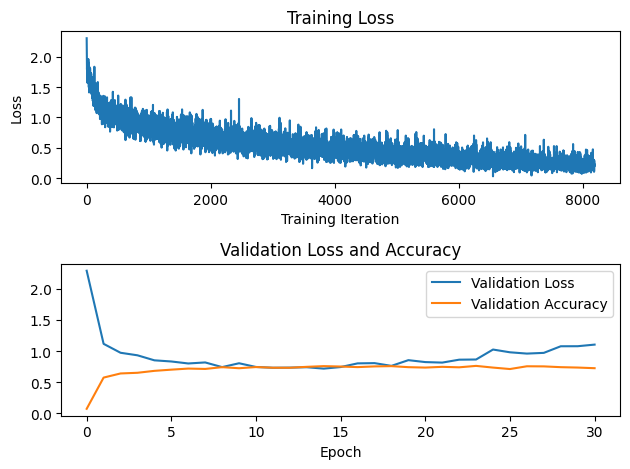

In [13]:
fig, (ax1, ax2) = plt.subplots(2, 1)

ax1.plot(train_losses)
ax2.plot(val_losses, label='Validation Loss')
ax2.plot(val_accs, label='Validation Accuracy')

ax1.set_title('Training Loss')
ax1.set_xlabel('Training Iteration')
ax1.set_ylabel('Loss')
ax2.set_title('Validation Loss and Accuracy')
ax2.set_xlabel('Epoch')
ax2.legend()

plt.tight_layout()
plt.show()

If the model predicts the correct class but with lower probability, accuracy is unchanged but loss increases, because accuracy only considers the correctness of the predicted class, not the confidence.

### (e)

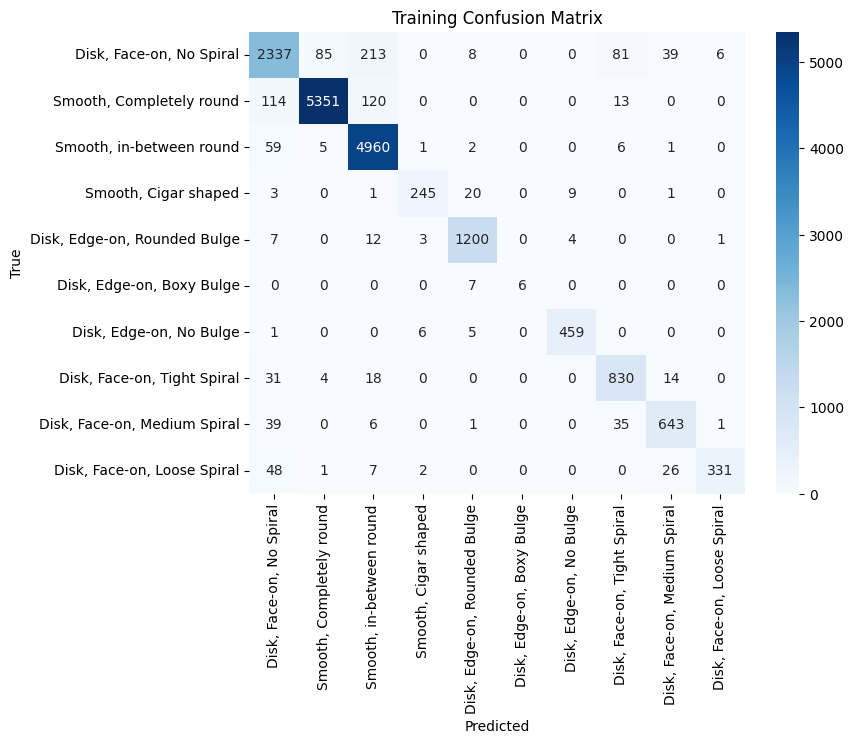

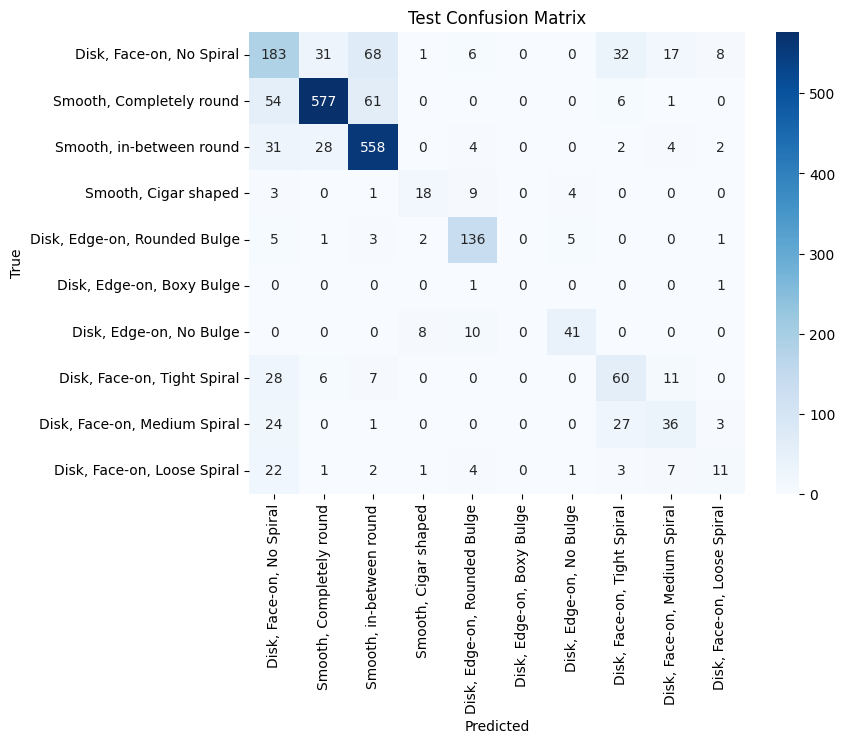

In [14]:
# TODO: Plot the confusion matrix

from sklearn.metrics import confusion_matrix
import seaborn as sns

def compute_confusion_matrix(model, dataloader, device):
    model.eval()
    all_preds = []
    all_labels = []

    with t.no_grad():
        for inputs, targets in dataloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            _, predicted = outputs.max(1)
            all_preds.append(predicted.cpu())
            all_labels.append(targets.cpu())

    all_preds = t.cat(all_preds)
    all_labels = t.cat(all_labels)

    cm = confusion_matrix(all_labels.numpy(), all_preds.numpy())
    return cm

def plot_confusion_matrix(cm, label_names, title="Confusion Matrix"):
    plt.figure(figsize=(8,6))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=label_names, yticklabels=label_names)
    plt.xlabel("Predicted")
    plt.ylabel("True")
    plt.title(title)
    plt.show()

# Confusion matrix for training set
cm_train = compute_confusion_matrix(model, train_loader, device)
plot_confusion_matrix(cm_train, label_names, title="Training Confusion Matrix")

# Confusion matrix for validation/test set
cm_val = compute_confusion_matrix(model, test_loader, device)
plot_confusion_matrix(cm_val, label_names, title="Test Confusion Matrix")

### (f)

In [22]:
# TODO: Plot the convolutional kernels of the first CNN layer


kernels = model.conv1.weight.data.cpu() 
print(kernels.shape)

kernels_min = kernels.min()
kernels_max = kernels.max()
kernels_normalized = (kernels - kernels_min) / (kernels_max - kernels_min)

torch.Size([8, 3, 5, 5])


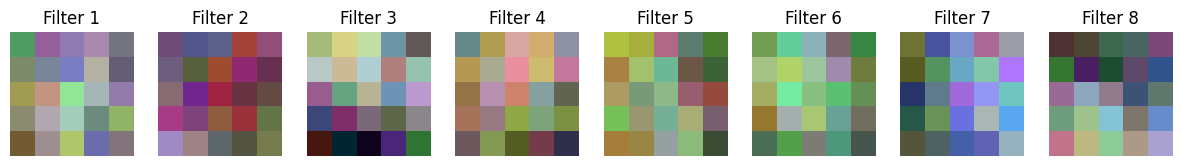

In [ ]:
num_kernels = kernels_normalized.shape[0]
fig, axes = plt.subplots(1, num_kernels, figsize=(15, 2))

for i in range(num_kernels):
    # shape: [3, 5, 5] → [5, 5, 3] for plotting
    kernel_img = kernels_normalized[i].permute(1, 2, 0).numpy()
    axes[i].imshow(kernel_img)
    axes[i].axis('off')
    axes[i].set_title(f"Kernel {i+1}")

plt.show()

### (g)

For invariance w.r.t $n\cdot 90^\circ$ rotation: Rotate images during training  
For arbitrary rotation: Bessel-CNNs: https://proceedings.neurips.cc/paper/2021/file/f18224a1adfb7b3dbff668c9b655a35a-Paper.pdf